Dataset cargado exitosamente.


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
,<chr>,<ord>,<ord>,<ord>,<ord>,<ord>,<fct>,<fct>,<fct>,<fct>,<fct>
1,1000025,5,1,1,1,2,1,3,1,1,benign
2,1002945,5,4,4,5,7,10,3,2,1,benign
3,1015425,3,1,1,1,2,2,3,1,1,benign
4,1016277,6,8,8,1,3,4,3,7,1,benign
5,1017023,4,1,1,3,2,1,3,1,1,benign
6,1017122,8,10,10,8,7,10,9,7,1,malignant


'data.frame':	699 obs. of  11 variables:
 $ Id             : chr  "1000025" "1002945" "1015425" "1016277" ...
 $ Cl.thickness   : Ord.factor w/ 10 levels "1"<"2"<"3"<"4"<..: 5 5 3 6 4 8 1 2 2 4 ...
 $ Cell.size      : Ord.factor w/ 10 levels "1"<"2"<"3"<"4"<..: 1 4 1 8 1 10 1 1 1 2 ...
 $ Cell.shape     : Ord.factor w/ 10 levels "1"<"2"<"3"<"4"<..: 1 4 1 8 1 10 1 2 1 1 ...
 $ Marg.adhesion  : Ord.factor w/ 10 levels "1"<"2"<"3"<"4"<..: 1 5 1 1 3 8 1 1 1 1 ...
 $ Epith.c.size   : Ord.factor w/ 10 levels "1"<"2"<"3"<"4"<..: 2 7 2 3 2 7 2 2 2 2 ...
 $ Bare.nuclei    : Factor w/ 10 levels "1","2","3","4",..: 1 10 2 4 1 10 10 1 1 1 ...
 $ Bl.cromatin    : Factor w/ 10 levels "1","2","3","4",..: 3 3 3 3 3 9 3 3 1 2 ...
 $ Normal.nucleoli: Factor w/ 10 levels "1","2","3","4",..: 1 2 1 7 1 7 1 1 1 1 ...
 $ Mitoses        : Factor w/ 9 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 5 1 ...
 $ Class          : Factor w/ 2 levels "benign","malignant": 1 1 1 1 1 2 1 1 1 1 ...


      Id             Cl.thickness   Cell.size     Cell.shape  Marg.adhesion
 Length:699         1      :145   1      :384   1      :353   1      :407  
 Class :character   5      :130   10     : 67   2      : 59   2      : 58  
 Mode  :character   3      :108   3      : 52   10     : 58   3      : 58  
                    4      : 80   2      : 45   3      : 56   10     : 55  
                    10     : 69   4      : 40   4      : 44   4      : 33  
                    2      : 50   5      : 30   5      : 34   8      : 25  
                    (Other):117   (Other): 81   (Other): 95   (Other): 63  
  Epith.c.size  Bare.nuclei   Bl.cromatin  Normal.nucleoli    Mitoses   
 2      :386   1      :402   2      :166   1      :443     1      :579  
 3      : 72   10     :132   3      :165   10     : 61     2      : 35  
 4      : 48   2      : 30   1      :152   3      : 44     3      : 33  
 1      : 47   5      : 30   7      : 73   2      : 36     10     : 14  
 6      : 41   3      : 28 

Cl.thickness       Cell.size      Cell.shape   Marg.adhesion    Epith.c.size 
              0               0               0               0               0 
    Bare.nuclei     Bl.cromatin Normal.nucleoli         Mitoses           Class 
             16               0               0               0               0

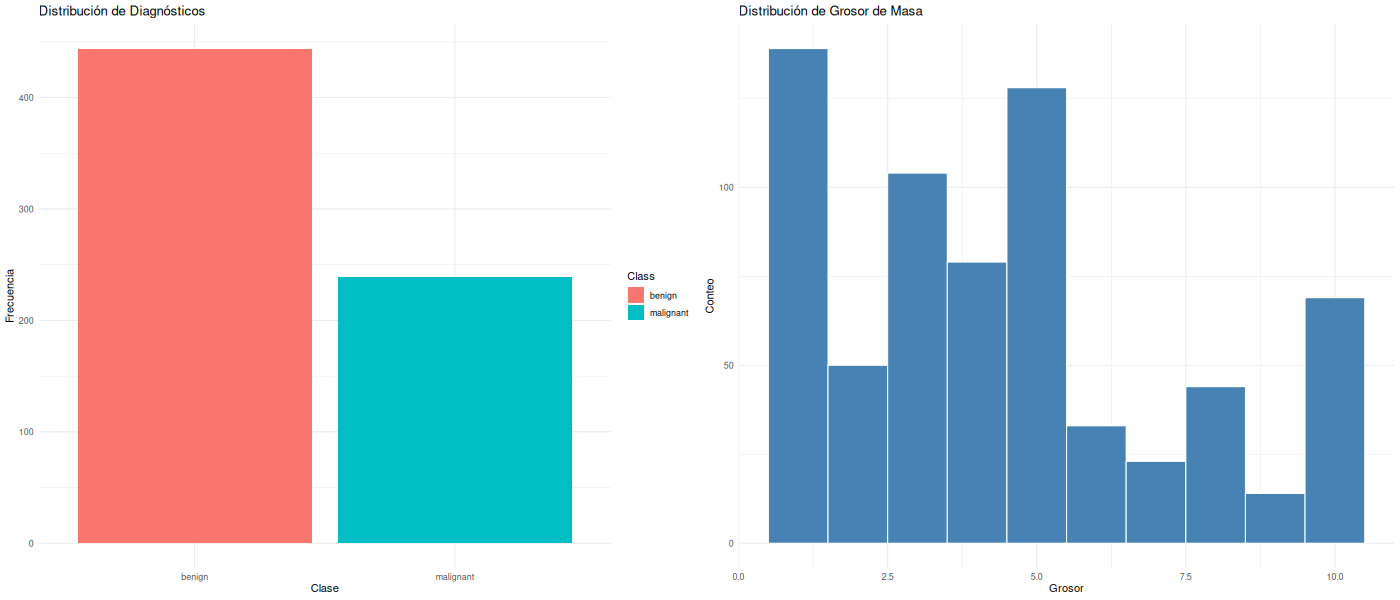

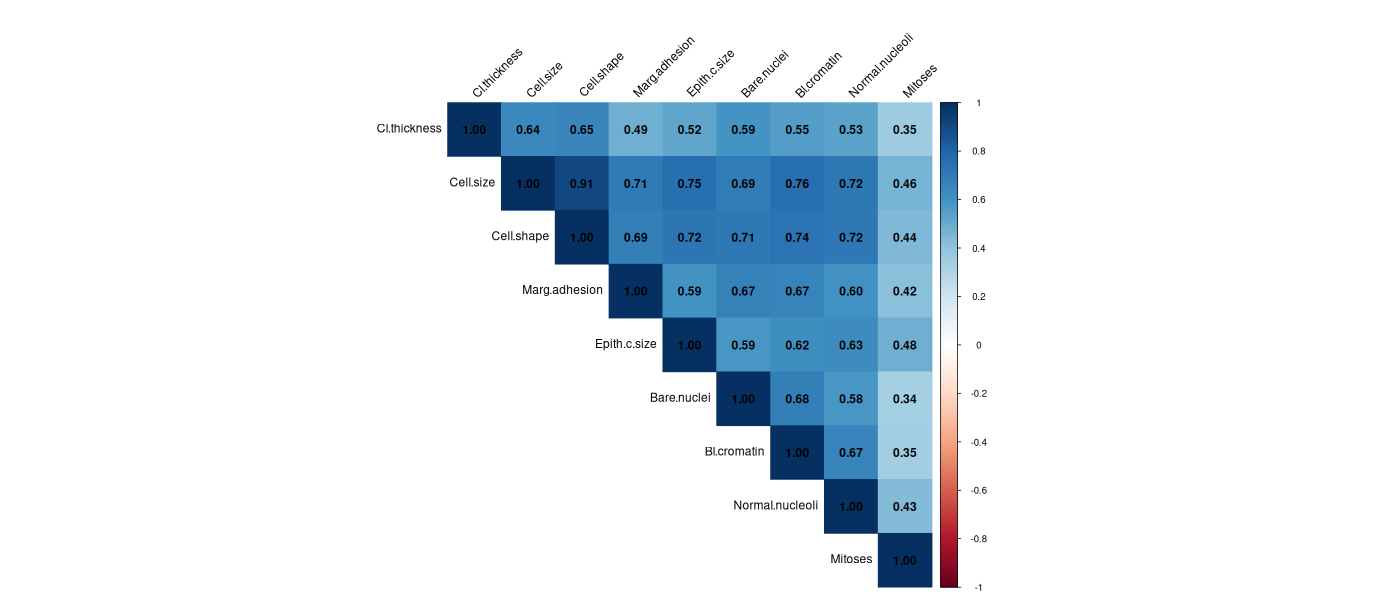

ERROR: Error in pivot_longer(., cols = -Class, names_to = "Caracteristica", values_to = "Valor"): no se pudo encontrar la función "pivot_longer"


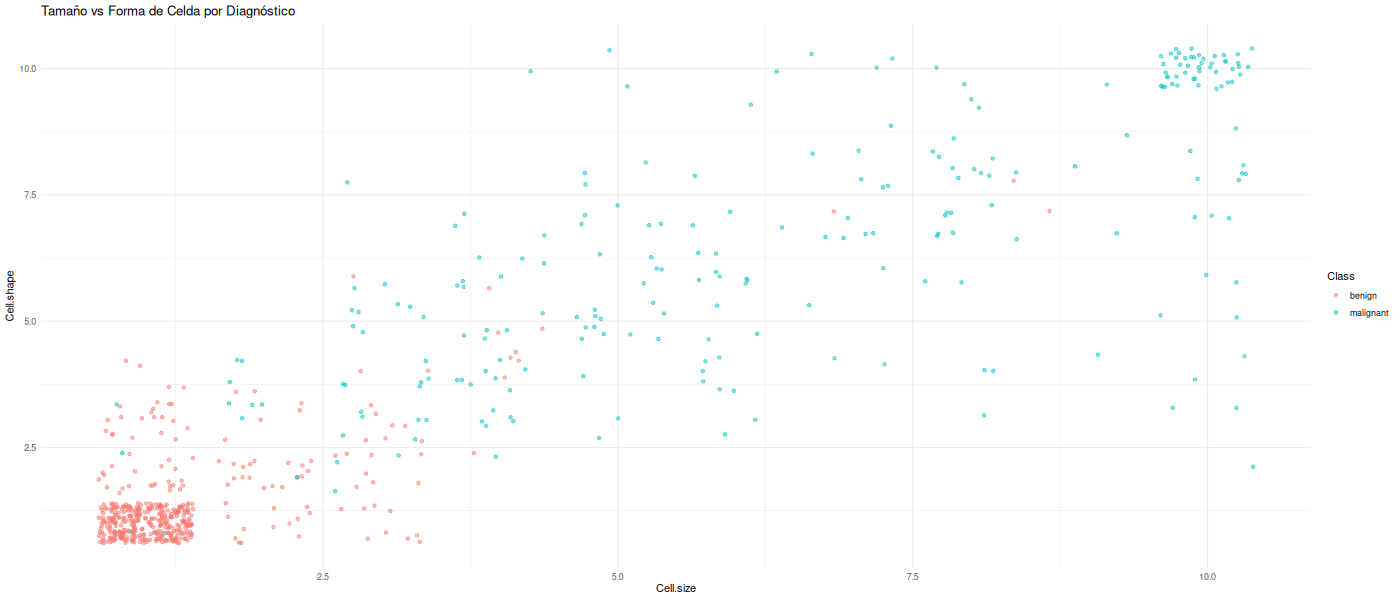

In [6]:
# Instalación (si es necesario) y carga de librerías
#if(!require(mlbench)) install.packages("mlbench")
#if(!require(tidyverse)) install.packages("tidyverse")
#if(!require(corrplot)) install.packages("corrplot")

library(mlbench)
library(dplyr)
library(corrplot)
library(ggplot2)

# Carga del dataset
data(BreastCancer)
df <- BreastCancer


cat("Dataset cargado exitosamente.\n")

#------------------------------------------------------------
# Etapa 2: Inspección Inicial y Estructura
#------------------------------------------------------------
# Visualización de las primeras filas
head(df)

# Estructura del dataset (tipos de datos)
str(df)

# Resumen estadístico descriptivo
summary(df)


#------------------------------------------------------------
#Etapa 3: Limpieza de Datos
#------------------------------------------------------------
# Eliminamos la columna ID ya que no aporta valor estadístico
df <- df %>% select(-Id)

# Conversión de columnas de factores a numéricas (excepto la variable objetivo 'Class')
df_numeric <- df
df_numeric[,-10] <- sapply(df_numeric[,-10], function(x) as.numeric(as.character(x)))

# Verificación de valores faltantes (NA)
colSums(is.na(df_numeric))

# Eliminamos filas con NAs para este ejemplo
df_clean <- na.omit(df_numeric)

#------------------------------------------------------------
# Etapa 4: Análisis Univariado (Distribuciones)
#------------------------------------------------------------
# Ajuste de tamaño para Jupyter: 700 px por gráfico (2 gráficos en una fila = 1400 px total)
options(repr.plot.width = 1400 / 72, repr.plot.height = 600 / 72, repr.plot.res = 72)

# Distribución de la variable objetivo
p1 <- ggplot(df_clean, aes(x = Class, fill = Class)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Distribución de Diagnósticos", x = "Clase", y = "Frecuencia")

# Histograma de una característica (ej. Clump Thickness)
p2 <- ggplot(df_clean, aes(x = Cl.thickness)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  theme_minimal() +
  labs(title = "Distribución de Grosor de Masa", x = "Grosor", y = "Conteo")

# Mostrar ambos gráficos en 1 fila y 2 columnas
gridExtra::grid.arrange(p1, p2, ncol = 2)

options(repr.plot.width = 1400 / 72, repr.plot.height = 600 / 72, repr.plot.res = 72)
#------------------------------------------------------------
# Etapa 5: Análisis Bivariado y Correlaciones
#------------------------------------------------------------
# Matriz de correlación (excluyendo la columna Class)
cor_matrix <- cor(df_clean[,-10])

# Visualización del Mapa de Calor
corrplot(cor_matrix, method = "color", type = "upper", 
         tl.col = "black", tl.srt = 45, addCoef.col = "black")

# Relación entre Cel.size y Cel.shape coloreado por Clase
ggplot(df_clean, aes(x = Cell.size, y = Cell.shape, color = Class)) +
  geom_jitter(alpha = 0.5) + # Usamos jitter porque los datos son discretos (1-10)
  theme_minimal() +
  labs(title = "Tamaño vs Forma de Celda por Diagnóstico")

#------------------------------------------------------------
# Etapa 6: Identificación de Valores Atípicos (Outliers)
#------------------------------------------------------------
# Transformamos los datos a formato largo para graficar múltiples boxplots
df_long <- df_clean %>%
  pivot_longer(cols = -Class, names_to = "Caracteristica", values_to = "Valor")

# Gráfico de Boxplots
ggplot(df_long, aes(x = Caracteristica, y = Valor, fill = Caracteristica)) +
  geom_boxplot() +
  coord_flip() + # Giramos para mejor lectura
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "Detección de Outliers en Características", x = "", y = "Valor (Escala 1-10)")